CASE A: SUSTAINED RESPONSE
F = 1.0 kf = 1.0 k1 = 1.0 
k7 = 3.0 k11 = 3.75 t_fin = 50


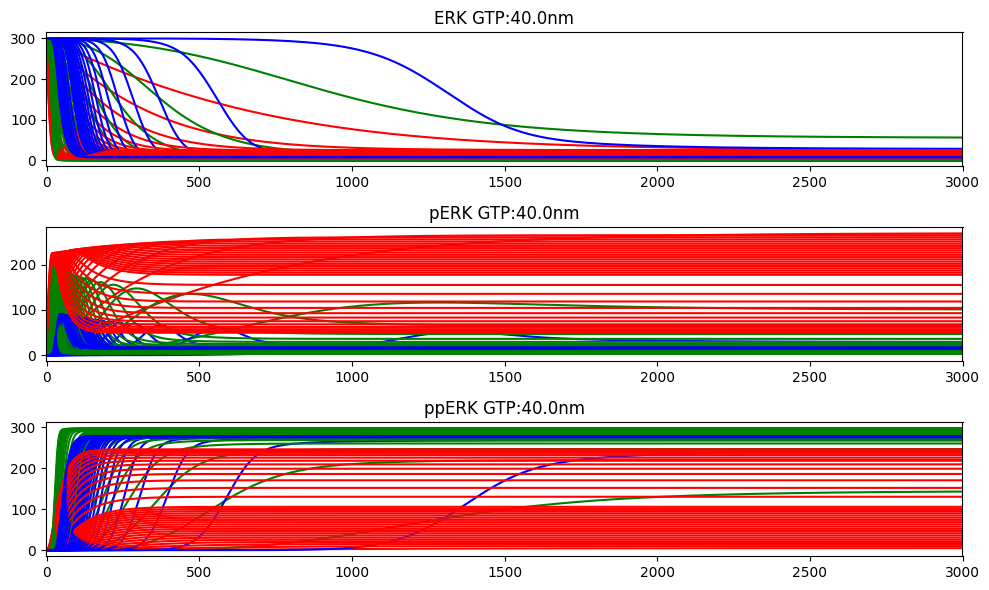

In [64]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#get_ipython().run_line_magic('matplotlib', 'notebook')
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
%matplotlib inline
#Parameter values
nequ    = 9
k1      = 1.0   # k1_cat
km1     = 100.0
km2     = 200.0
k2      = 0.25  # k2_cat
k3      = 2.5   # Vmax_3
km3     = 50.0
km4     = 100.0
k4      = 3.75  # Vmax_4
k5      = 2.5   # k5_cat
km5     = 250.0
km6     = 250.0
k6      = 0.5   # k6_cat
k7      = 3.0   # Vmax_7
km7     = 250.0
km8     = 80.0
k8      = 3.75  # Vmax_8
k9      = 0.125 # k9_cat
km9     = 250.0
km10    = 250.0 
k10     = 0.125 # k10_cat
k11     = 3.75  # Vmax_11
km11    = 120.0
km12    = 20.0
k12     = 5.0   # Vmax_12
km13    = 300.0 


#------------------------------------------------------------------#
#initial conditions
initial = [0] * nequ
initial[0] = initial[3] = initial[6] = 300.0 # RAF - MEK - ERK

SUSTAINED   = True
TRANSIENT   = False
OSCILLATORY = False
BISTABLE    = False



# SUSTAINED SIGNALLING
if SUSTAINED==True: 
    F   = 1.0 # no feedback
    kf  = 1.0 # irrelevant if F=1.0
    k1  = 1.0  # nM / s
    k7  = 3.0  # nM / s
    k11 = 3.75 # nM / s
    GTP_INTITAL = [0]*10 # nM [1-10]
    tmax        = 50 # min
    print("CASE A: SUSTAINED RESPONSE")
    print(f"F = {F} kf = {kf} k1 = {k1} \nk7 = {k7} k11 = {k11} t_fin = {tmax}")
    _CASE = "CASE A: SUSTAINED RESPONSE"
    

# TRANSIENT w ADAPTATION
if TRANSIENT==True:
    F   = 0.01
    kf  = 1.0   # nM
    k7  = 0.175 # nM / s
    k1  = 1.0   # nM / s
    k11 = 3.75  # nM / s
    GTP_INTITAL = 10 # nM
    tmax        = 120 # min
    print("CASE B: TRANSIENT RESPONSE")
    print(f"F = {F} kf = {kf} k1 = {k1} \nk7 = {k7} k11 = {k11} t_fin = {tmax}")
    _CASE = "CASE B: TRANSIENT RESPONSE"
    _PARAMS = f"F = {F}, " + r"$k_{{f}}=$" + f" {kf}, " + r"$k_{{1}}=$" + f" {k1},  " + r"$k_{{7}}=$" + f" {k7}, " + r"$k_{{11}}=$" + f" {k11},  "+r"$t_{{fin}}=$"+f"{tmax}"

# OSCILLATORY 
if OSCILLATORY==True:
    F   = 0.01
    kf  = 25.0 # nM / s
    k7  = 3.0 # nM / s
    k1  = 1.0 # nM / s
    k11 = 3.75 # nM / s
    GTP_INTITAL = 10 # nM
    tmax        = 120 # min
    print("CASE C: OSCILLATORY RESPONSE")
    print(f"F = {F} kf = {kf} k1 = {k1} \nk7 = {k7} k11 = {k11} t_fin = {tmax}")
    _CASE = "CASE C: OSCILLATORY RESPONSE"
    _PARAMS = f"F = {F}, " + r"$k_{{f}}=$" + f" {kf}, " + r"$k_{{1}}=$" + f" {k1},  " + r"$k_{{7}}=$" + f" {k7}, " + r"$k_{{11}}=$" + f" {k11},  "+r"$t_{{fin}}=$"+f"{tmax}"

# BISTABLE
if BISTABLE==True:
    F   = 5.0
    kf  = 100.0 #nM
    k1  = 0.025 #nM/s
    k11 = 0.025 #nM/s
    k7  = 3.0 #nM/s
    GTP_INTITAL = 10 # nM
    tmax        = 250 # min
    initial[8]  = 30.0                  # ppERK
    initial[6]  = 300.0 - initial[8]         # ERK
    print("CASE D: BISTABLE RESPONSE")
    print(f"F = {F} kf = {kf} k1 = {k1} \nk7 = {k7} k11 = {k11} t_fin = {tmax}")
    _CASE = "CASE D: BISTABLE RESPONSE"
    _PARAMS = f"F = {F}, " + r"$k_{{f}}=$" + f" {kf}, " + r"$k_{{1}}=$" + f" {k1},  " + r"$k_{{7}}=$" + f" {k7}, " + r"$k_{{11}}=$" + f" {k11},  "+r"$t_{{fin}}=$"+f"{tmax}"
_PARAMS = f"F = {F}, " + r"$k_{{f}}=$" + f" {kf}nM/s, " + r"$k_{{1}}=$" + f" {k1}nM/s,  " + r"$k_{{7}}=$" + f" {k7}nM/s, " + r"$k_{{11}}=$" + f" {k11}nM/s,  "+r"$t_{{fin}}=$"+f"{tmax}"
#------------------------------------------------------------------#
#Derivatives
def dy_dt(y,t):
    RAF, pRAF, ppRAF, MEK, pMEK, ppMEK, ERK, pERK, ppERK = y

    v1 = ( ( (k1*gtp*RAF)   / km1 ) / ( 1+(RAF/km1)+(pRAF/km2) ) ) * ( (1+(F*ppERK)/kf) /  (1+(ppERK)/kf))
    v2 = ( ( (k2*gtp*pRAF)  / km2 ) / ( 1+(RAF/km1)+(pRAF/km2) ) ) * ( (1+(F*ppERK)/kf) /  (1+(ppERK)/kf))
    v3 = ( (k3*ppRAF) / km3 )       / ( 1+(ppRAF/km3)+(pRAF/km4) )
    v4 = ( (k4*ppRAF) / km4 )       / ( 1+(ppRAF/km3)+(pRAF/km4) )

    v5 = ( (k5*ppRAF*MEK)  / km5 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v6 = ( (k6*ppRAF*pMEK) / km6 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v7 = ( (k7*ppMEK) / km7 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )
    v8 = ( (k8*pMEK)  / km8 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )

    v9  = ( (k9*ppMEK*ERK)   / km9 )   / ( 1+(ERK/km9)+(pERK/km10) )
    v10 = ( (k10*ppMEK*pERK) / km10 )  / ( 1+(ERK/km9)+(pERK/km10) )
    v11 = ( (k11*ppERK) / km11 )       / ( 1+(ppERK/km11)+(pERK/km12) ) # +(ERK/km13)
    v12 = ( (k12*pERK)  / km12 )       / ( 1+(ppERK/km11)+(pERK/km12) ) # +(ERK/km13)
    
    dy = []
    dy.append( v4 - v1 )           # RAF
    dy.append( v1 - v2 + v3 - v4 ) # pRAF
    dy.append( v2 - v3 )           # ppRAF

    dy.append( v8 - v5 )           # MEK
    dy.append( v5 - v6 + v7 - v8 ) # pMEK
    dy.append( v6 - v7 )           # ppMEK

    dy.append( v12 - v9 )             # ERK
    dy.append( v9 - v10 + v11 - v12 ) # pERK
    dy.append( v10 - v11 )            # ppERK
    return dy    

#Integration of ODEs
GTP = np.arange(0.5,10.5,0.5)
GTP=np.append(GTP,np.arange(12.5,42.5,2.5))
fig, ax = plt.subplots(3,1, figsize=(10,6))
lines = []
colors=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue', 'blue']
cols=["Raf", "pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"]
STEADYSTATE_DETERMINISTIC = []
for gtp in GTP:
    #initial conditions
    y0=initial.copy()
    
    t_min = tmax
    t = np.linspace(0, t_min * 60 + 1, 10000)
    sol = odeint(func=dy_dt, y0=y0, t=t)
    lines.append(sol)
    sol = pd.DataFrame(sol, columns=["Raf", "pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"])
    
    # HERE
    #lines.append(sol.values)
    means = sol.tail(20).mean()
    STEADYSTATE_DETERMINISTIC.append(means.values)
    sol.index = t
    sol.index = sol.index/60
    
    #fig, ax = plt.subplots(3,1, figsize=(10,6))
    colors=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue', 'blue']
    for i, col in enumerate(sol.columns):
        r = i // 3
        c = i % 3
        # print init cond.
        #print(f"{cols[i]}:[{initial[i]:.1f}]", end='-' if c!=2 else "\n")
        
        ax[c].plot(t, sol[col], color=colors[i], label=col)
        ax[c].set_title(f'{col} GTP:{gtp}nm')
        #ax[c].legend()
        ax[c].set_xlim(-2,t_min*60)
STEADYSTATE_DETERMINISTIC = pd.DataFrame(
    STEADYSTATE_DETERMINISTIC,
    columns=sol.columns,
    index=GTP
)
plt.tight_layout()
plt.show()

In [2]:
##--FUNCTION FOR STOCHASTIC STOCHIOMETRIC GILLESPIE ALGORITHM--##
NA = 6.022e23
V  = 1e-15
CONV = 1e-9 * NA * V
INV_CONV = 1.0 / CONV

def conc_to_counts(c_nM):
    return int(round(c_nM * CONV))

def counts_to_conc(x_counts):
    return x_counts * INV_CONV

def gillespie_mapk(g0, tmax):

    # --- concentrations → molecule counts ---
    state = np.round(np.array(g0) * CONV).astype(int)

    t = 0.0
    times = [t]
    traj_counts = [state.copy()]
    traj_conc   = [state * INV_CONV]
    taus = []
    reactions = []

    while t < tmax:

        # unpack counts
        RAF_S, pRAF_S, ppRAF_S, MEK_S, pMEK_S, ppMEK_S, ERK_S, pERK_S, ppERK_S = state

        # convert to concentrations for rate laws
        RAF, pRAF, ppRAF, MEK, pMEK, ppMEK, ERK, pERK, ppERK = state * INV_CONV

        # --- propensities (convert to counts-based by multiplying by V*NA) ---
        v1 = ( ( (k1*gtp*RAF)   / km1 ) / (1+(RAF/km1)+(pRAF/km2)) ) * ( (1+(F*ppERK)/kf) / (1+(ppERK)/kf) )
        v2 = ( ( (k2*gtp*pRAF)  / km2 ) / (1+(RAF/km1)+(pRAF/km2)) ) * ( (1+(F*ppERK)/kf) / (1+(ppERK)/kf) )
        v3 = ( (k3*ppRAF) / km3 )       / (1+(ppRAF/km3)+(pRAF/km4))
        v4 = ( (k4*ppRAF) / km4 )       / (1+(ppRAF/km3)+(pRAF/km4))

        v5 = ( (k5*ppRAF*MEK)  / km5 )  / (1+(MEK/km5)+(pMEK/km6))
        v6 = ( (k6*ppRAF*pMEK) / km6 )  / (1+(MEK/km5)+(pMEK/km6))
        v7 = ( (k7*ppMEK) / km7 )       / (1+(ppMEK/km7)+(pMEK/km8))
        v8 = ( (k8*pMEK)  / km8 )       / (1+(ppMEK/km7)+(pMEK/km8))

        v9  = ( (k9*ppMEK*ERK)   / km9 )   / (1+(ERK/km9)+(pERK/km10))
        v10 = ( (k10*ppMEK*pERK) / km10 )  / (1+(ERK/km9)+(pERK/km10))
        v11 = ( (k11*ppERK) / km11 )       / (1+(ppERK/km11)+(pERK/km12))
        v12 = ( (k12*pERK)  / km12 )       / (1+(ppERK/km11)+(pERK/km12))

        # convert rates (nM/s) → molecule propensities
        a = np.array([v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12]) * CONV
        a0 = a.sum()

        if a0 <= 0:
            break

        # time step
        tau = -np.log(np.random.rand()) / a0
        t += tau
        taus.append(tau)

        # Modifying it to have reactions per tau
        #REACTIONS_PER_TAU = np.random.randint(1,12)
        REACTIONS_PER_TAU = 1
        for _ in range(REACTIONS_PER_TAU):
            # reaction selection
            r2 = np.random.rand() * a0
            reaction = np.searchsorted(np.cumsum(a), r2)
            reactions.append(reaction)
            # --- state updates ---
            if reaction == 0 and RAF_S > 0:
                state[0] -= 1; state[1] += 1
            elif reaction == 1 and state[1] > 0:
                state[1] -= 1; state[2] += 1
            elif reaction == 2 and state[2] > 0:
                state[2] -= 1; state[1] += 1
            elif reaction == 3 and state[1] > 0:
                state[1] -= 1; state[0] += 1

            elif reaction == 4 and state[3] > 0:
                state[3] -= 1; state[4] += 1
            elif reaction == 5 and state[4] > 0:
                state[4] -= 1; state[5] += 1
            elif reaction == 6 and state[5] > 0:
                state[5] -= 1; state[4] += 1
            elif reaction == 7 and state[4] > 0:
                state[4] -= 1; state[3] += 1

            elif reaction == 8 and state[6] > 0:
                state[6] -= 1; state[7] += 1
            elif reaction == 9 and state[7] > 0:
                state[7] -= 1; state[8] += 1
            elif reaction == 10 and state[8] > 0:
                state[8] -= 1; state[7] += 1
            elif reaction == 11 and state[7] > 0:
                state[7] -= 1; state[6] += 1
            
        # store
        times.append(t)
        traj_counts.append(state.copy())
        traj_conc.append(state * INV_CONV)

    return np.array(times), np.array(traj_conc), np.array(traj_counts), taus, reactions

In [65]:
##  GILLESPISE SIM ##
minutes = tmax
TMAX = 60 * minutes # -> seconds for sim
STEADYSTATE_STOCHASTIC   = []
STEADYSTATE_STOCHASTIC_2 = []
# --- INITIAL CONDITIONS (concentrations) --- (TODO: Is necessary?)
c0 = np.zeros(9)
c0[0] = 300   # RAF (nM)
c0[3] = 300   # MEK
c0[6] = 300   # ERK
c0[8] = 20    # ppERK
c0[6] -= c0[8]
c0=initial
d0=initial

for gtp in GTP:
    
    t, traj, traj_counts, tau_dist, reaction_dist            = gillespie_mapk(c0, TMAX)
    t_2, traj_2, traj_counts_2, tau_dist_2, reaction_dist_2  = gillespie_mapk(d0, TMAX)

    means = np.mean(traj[-20:,:], axis=0)
    means_2 = np.mean(traj_2[-20:,:], axis=0)

    STEADYSTATE_STOCHASTIC.append(means)
    STEADYSTATE_STOCHASTIC_2.append(means_2)
STEADYSTATE_STOCHASTIC = pd.DataFrame(
    STEADYSTATE_STOCHASTIC,
    columns=cols,
    index=GTP
)
STEADYSTATE_STOCHASTIC_2 = pd.DataFrame(
    STEADYSTATE_STOCHASTIC_2,
    columns=cols,
    index=GTP
)
_GTP = gtp
#  FOR TIME AXIS
t_ = np.linspace(0, t[-1], len(t))


In [ ]:
## TIME LAG TO VERIFY GILLESPIE DIST ## (LONG)
mean_reaction_dist=[]
mean_tau_dist=[]
for r in range(1,len(reaction_dist)):
    mean_reaction_dist.append(np.mean(reaction_dist[:r]))
for _tau in range(1,len(tau_dist)):
    mean_tau_dist.append(np.mean(np.log(tau_dist[:_tau])))

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[1].plot(t[2:],mean_reaction_dist)
ax[1].plot(t[2:],mean_tau_dist)
ax[0].hist([np.log(tau_dist), np.log(tau_dist_2)], bins=20)
#ax[1].hist([reaction_dist, reaction_dist_2])
half = int(len(reaction_dist)/2)
#ax[1].hist([reaction_dist[:1000], reaction_dist_2[:1000]])

plt.show()

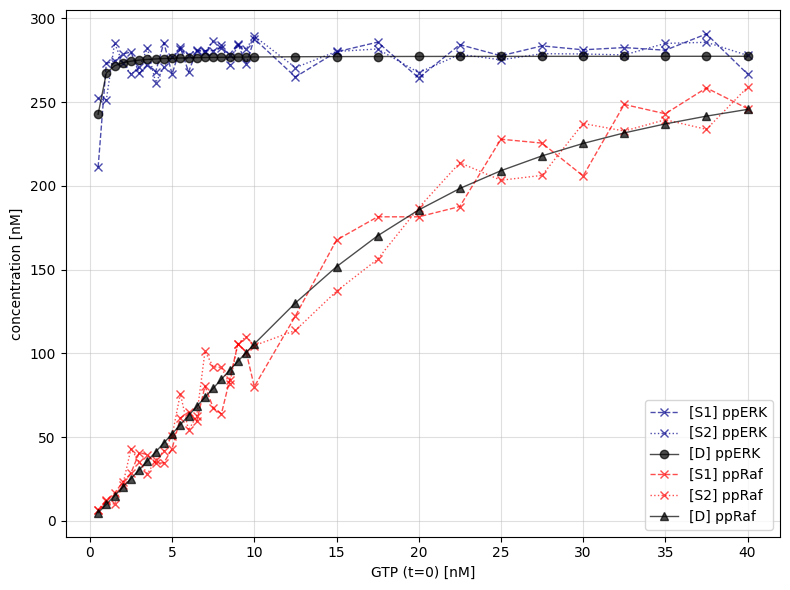

In [70]:
fig, ax = plt.subplots(1,1, figsize=(8,6))

ax.set_xlabel("GTP (t=0) [nM]")
ax.set_ylabel("concentration [nM]")

linestyles=['--','--','--',':',':',':','-.','-.','-.']
markers_steadystate=[".","^","x", ".","^","x", ".","^","x"]
colors_steadystate=["red"]*3 + ['darkgreen']*3 + ['darkblue']*3

PLOT_STEADYSTATE = True
## PLOT ppRAF and ppERK vs GTP init. conc.
if PLOT_STEADYSTATE==True:
        # ppERK (plotted first so legend at top)
        #------------------------------------------------------------------# ppERK
        ax.plot(GTP, STEADYSTATE_STOCHASTIC['ppERK'], 
                linestyle=linestyles[2], 
                marker=markers_steadystate[8], 
                color=colors_steadystate[8],
                alpha=0.7,
                linewidth=1,
                label="[S1] ppERK"
                )
        
        ax.plot(GTP, STEADYSTATE_STOCHASTIC_2['ppERK'], 
                linestyle=linestyles[5], 
                marker=markers_steadystate[8], 
                color=colors_steadystate[8],
                alpha=0.7,
                linewidth=1,
                label="[S2] ppERK"
                )
        ax.plot(GTP, STEADYSTATE_DETERMINISTIC['ppERK'], 
                linestyle="-", 
                marker='o',
                fillstyle='full', 
                color='black',
                alpha=0.7,
                linewidth=1,
                label="[D] ppERK"
                )
        #------------------------------------------------------------------# ppRaf
        ax.plot(GTP, STEADYSTATE_STOCHASTIC['ppRaf'], 
                linestyle=linestyles[2], 
                marker=markers_steadystate[2], 
                color=colors_steadystate[2],
                alpha=0.7,
                linewidth=1,
                label="[S1] ppRaf"
                )
        ax.plot(GTP, STEADYSTATE_STOCHASTIC_2['ppRaf'], 
                linestyle=linestyles[5], 
                marker=markers_steadystate[2], 
                color=colors_steadystate[2],
                alpha=0.7,
                linewidth=1,
                label="[S2] ppRaf"
                )
        ax.plot(GTP, STEADYSTATE_DETERMINISTIC['ppRaf'], 
                linestyle="-", 
                marker='^',
                fillstyle='full', 
                color='black',
                alpha=0.7,
                linewidth=1,
                label="[D] ppRaf"
                )
else:
        for _, c in enumerate(cols):
                ax.plot(GTP, STEADYSTATE_STOCHASTIC[c], 
                        linestyle=linestyles[_], 
                        marker=markers_steadystate[_], 
                        color=colors_steadystate[_],
                        alpha=0.7,
                        linewidth=1
                        )
                ax.plot(GTP, STEADYSTATE_DETERMINISTIC[c], 
                        linestyle="-", 
                        marker=markers_steadystate[_], 
                        color=colors_steadystate[_],
                        alpha=0.7,
                        linewidth=1
                        )
plt.tight_layout()
plt.grid(which='major', alpha=0.4)
ax.legend()
plt.show()

Text(0, 0.5, 'ppERK')

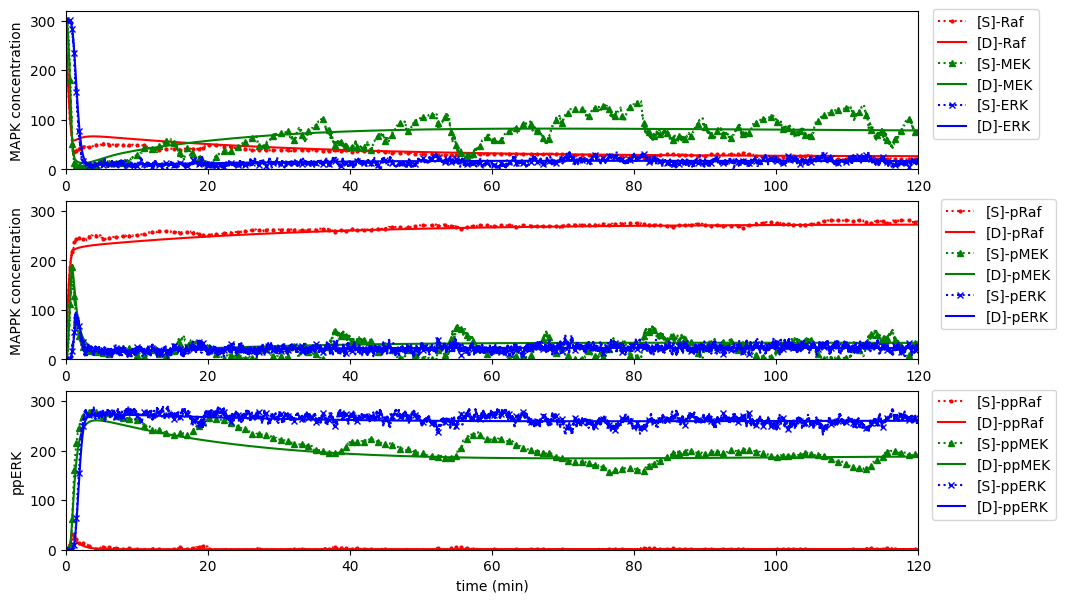

In [51]:
## GRAPH SIMULATIONS FOR DETERMINISTIC AND STOCHASTIC DYNAMICS ##
fig, ax = plt.subplots(3,1, figsize=(11,7))

for a in ax:
    a.set_xlim(0, t[-1]/60)
    a.set_ylim(0, 320)

colors = ['red','red','red','green','green','green','blue','blue','blue']
labels = ["Raf","pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"]
linestyles=['--','--','--',':',':',':','-','-','-']
markers=[".",".",".", "^","^","^", "x","x","x"]

for i in range(9):
    ax[i % 3].plot(t/60, traj[:,i], color=colors[i], marker=markers[i], markevery=250, markersize=4, linestyle=":", label="[S]-"+cols[i])
    ax[i % 3].plot(sol.index, sol[f"{labels[i]}"], color=colors[i], marker=None, markevery=20, markersize=4, linestyle='-', label="[D]-"+cols[i])

ax[0].set_ylabel("MAPK concentration")
ax[1].set_ylabel("MAPPK concentration")
ax[2].set_ylabel("MAPPPK concentration")
ax[2].set_xlabel("Time")
ax[0].legend(loc='right',bbox_to_anchor=(1.15, 0.6))
ax[1].legend(loc='right',bbox_to_anchor=(1.17, 0.6))
ax[2].legend(loc='right',bbox_to_anchor=(1.17, 0.6))
#plt.plot(t/60, traj[:,8])
plt.xlabel("time (min)")
plt.ylabel("ppERK")

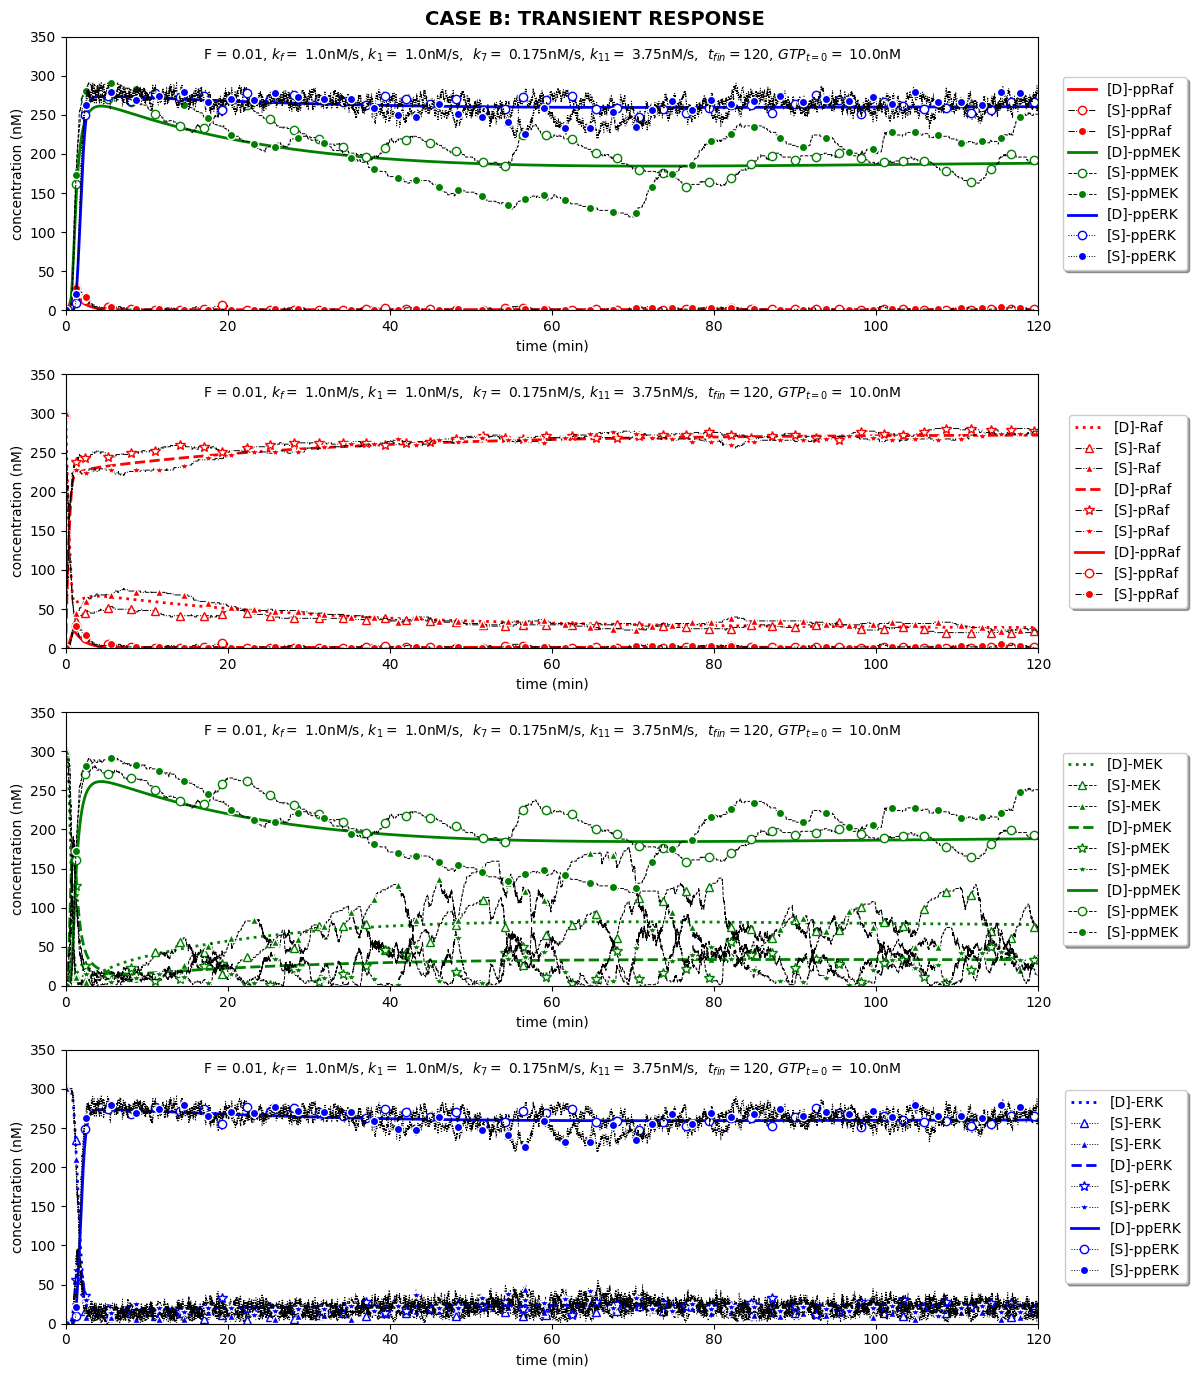

In [52]:

fig, ax = plt.subplots(4,1, figsize=(12,14))

for a in ax:
    a.set_xlim(0, t[-1]/60)
    a.set_ylim(0, 350)

colors          = ['red','red','red','green','green','green','blue','blue','blue']
colors          = ['black']*9
colors_det      = ['red']*3 + ['green']*3 + ['blue']*3
labels          = ["Raf","pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"]
linestyles      = ['-', '--', ':',  '-', '--', ':',  '-', '--', ':']
linestyles      = ['-.']*3 + ['--']*3 + [':']*3
linestyles_det  = [':',"--",'-']*3

markers         = ['^', '*', 'o', '^', '*', 'o', '^', '*', 'o']
markers_2       = ['^', '*', 'o', '^', '*', 'o', '^', '*', 'o']

mfcs            = ['white']*3 + ['white']*3 + ['white']*3
mecs            = ['red','red','red','green','green','green','blue','blue','blue']

mfcs_2          = ['red','red','red','green','green','green','blue','blue','blue']
mecs_2          = ['white']*9

widths          = [0.7]*9
markerfills     = ['full']*9
MARKEVERY = 750
MARKERSIZE = [6,7,6]*3

# COLORS HAVE BEEN SPECIFICALLY MODIFIED #
# (TODO: CHANGE FORMAT TO MODULAR)
# (TODO: CHANGE STYLE FOR CLARITY)
#   (TODO: ADD DETERMINISTIC WITH CLEAN STYLE)


# [PLOT 1] ---- ppRAF ppMEK ppERK ------------------------------------------------
proteins = [2,5,8]
for protein in proteins:
    # -- DETERMINISTIC --
    ax[0].plot(sol.index, sol[f"{labels[protein]}"], 
            color=colors_det[protein], marker='', linestyle=linestyles_det[protein], 
            linewidth=2, label="[D]-"+cols[protein])
    # -- STOCHASTIC --
    ax[0].plot(t/60, traj[:,protein], 
            color=colors[protein], marker=markers[protein], mfc=mfcs[protein], mec=mecs[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    ax[0].plot(t_2/60, traj_2[:,protein], 
            color=colors[protein], marker=markers_2[protein], mfc=mfcs_2[protein], mec=mecs_2[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    


# [PLOT 2] ---- RAF pRAF ppRAF ------------------------------------------------
proteins = [0,1,2]
for protein in proteins:
    # -- DETERMINISTIC --
    ax[1].plot(sol.index, sol[f"{labels[protein]}"], 
            color=colors_det[protein], marker='', linestyle=linestyles_det[protein], 
            linewidth=2, label="[D]-"+cols[protein])
    
    # -- STOCHASTIC --
    ax[1].plot(t/60, traj[:,protein], 
            color=colors[protein], marker=markers[protein], mfc=mfcs[protein], mec=mecs[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    ax[1].plot(t_2/60, traj_2[:,protein], 
            color=colors[protein], marker=markers_2[protein], mfc=mfcs_2[protein], mec=mecs_2[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    
    

# [PLOT 3] ---- MEK pMEK ppMEK ------------------------------------------------
proteins = [3,4,5]
for protein in proteins:
    # -- DETERMINISTIC --
    ax[2].plot(sol.index, sol[f"{labels[protein]}"], 
            color=colors_det[protein], marker='', linestyle=linestyles_det[protein], 
            linewidth=2, label="[D]-"+cols[protein])
    
    # -- STOCHASTIC --
    ax[2].plot(t/60, traj[:,protein], 
            color=colors[protein], marker=markers[protein], mfc=mfcs[protein], mec=mecs[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    ax[2].plot(t_2/60, traj_2[:,protein], 
            color=colors[protein], marker=markers_2[protein], mfc=mfcs_2[protein], mec=mecs_2[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    
    
    
# [PLOT 4] ---- ERK pERK ppERK ------------------------------------------------
proteins = [6,7,8]
for protein in proteins:
    # -- DETERMINISTIC --
    ax[3].plot(sol.index, sol[f"{labels[protein]}"], 
            color=colors_det[protein], marker='', linestyle=linestyles_det[protein], 
            linewidth=2, label="[D]-"+cols[protein])
    
    # -- STOCHASTIC -- 
    ax[3].plot(t/60, traj[:,protein], 
            color=colors[protein], marker=markers[protein], mfc=mfcs[protein], mec=mecs[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    ax[3].plot(t_2/60, traj_2[:,protein], 
            color=colors[protein], marker=markers_2[protein], mfc=mfcs_2[protein], mec=mecs_2[protein],
            markevery=MARKEVERY, fillstyle=markerfills[protein],
            markersize=MARKERSIZE[protein], linestyle=linestyles[protein], 
            linewidth=widths[protein], label="[S]-"+cols[protein])
    
    

#for i in range(9):
#    ax[i % 3].plot(sol.index, sol[f"{labels[i]}"], color=colors[i], marker=None, markevery=20, markersize=4, linestyle='-', label="[D]-"+cols[i])

ax[0].set_ylabel("concentration (nM)")
ax[1].set_ylabel("concentration (nM)")
ax[2].set_ylabel("concentration (nM)")
ax[3].set_ylabel("concentration (nM)")

ax[0].set_xlabel("time (min)")
ax[1].set_xlabel("time (min)")
ax[2].set_xlabel("time (min)")
ax[3].set_xlabel("time (min)")

ax[0].legend(loc='right',bbox_to_anchor=(1.16,0.5), fontsize=10, ncols=1,fancybox=True, shadow=True)
ax[1].legend(loc='right',bbox_to_anchor=(1.16,0.5), fontsize=10, ncols=1,fancybox=True, shadow=True)
ax[2].legend(loc='right',bbox_to_anchor=(1.16,0.5), fontsize=10, ncols=1,fancybox=True, shadow=True)
ax[3].legend(loc='right',bbox_to_anchor=(1.16,0.5), fontsize=10, ncols=1,fancybox=True, shadow=True)



details = rf"F={F}, $\k_{{f}}$={kf}, $\k_{{1}}$={k1}, $\k_{{7}}$={k7}, $\k_{{11}}$={k11} $\t_{{fin}}$={tmax}"

_PARAMS += r", $GTP_{{t=0}}=$" + f" {_GTP}nM"
ax[0].text(s=_PARAMS, x=int(tmax/2), y=320, ha='center', fontsize=10)
ax[1].text(s=_PARAMS, x=int(tmax/2), y=320, ha='center', fontsize=10)
ax[2].text(s=_PARAMS, x=int(tmax/2), y=320, ha='center', fontsize=10)
ax[3].text(s=_PARAMS, x=int(tmax/2), y=320, ha='center', fontsize=10)

plt.suptitle(_CASE, fontsize=14, weight='bold')

plt.tight_layout()
plt.show()